In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
from scipy.signal import find_peaks, butter, filtfilt

In [19]:
SAMPLING_RATE = 1 / 6.65e-6  # Hz, from Delta_X in .lvm header
SENSITIVITY = 2e-3            # V/Pa, microphone sensitivity
P_REF = 20e-6                 # Pa, reference pressure
N_BLADES = 2
SKIPROWS = 23

RPM_FOLDERS = {
    2250: r"C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\data\90_Deg\RPM2250",
    2950: r"C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\data\90_Deg\RPM2950",
    3000: r"C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\data\90_Deg\RPM3000",
    3600: r"C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\data\90_Deg\RPM3600",
    4500: r"C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\data\90_Deg\RPM4500",
    5700: r"C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\data\90_Deg\RPM5700",
}

In [20]:
def load_lvm(filepath):
    data = np.loadtxt(filepath, skiprows=SKIPROWS, delimiter='\t')
    if data.ndim < 2:
        raise ValueError("File has insufficient data")
    time = data[:, 0]
    voltage = data[:, 1]
    voltage = voltage - np.mean(voltage)  # remove DC offset
    return time, voltage

In [21]:
def highpass_filter(voltage, cutoff=20):
    nyq = SAMPLING_RATE / 2
    normal_cutoff = cutoff / nyq
    b, a = butter(4, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, voltage)

In [22]:
def compute_fft(voltage):
    N = len(voltage)
    window = np.hanning(N)
    voltage_windowed = voltage * window
    fft_vals = np.fft.rfft(voltage_windowed)
    freqs = np.fft.rfftfreq(N, 1/SAMPLING_RATE)
    pressure_fft = np.abs(fft_vals) / (N / 2) / SENSITIVITY
    spl = 20 * np.log10(pressure_fft / P_REF + 1e-10)
    return freqs, spl

In [23]:
def load_and_average(folder_path):
    files = glob.glob(os.path.join(folder_path, '*.lvm'))
    print(f"  Found {len(files)} files")
    
    all_spectra = []
    freqs = None
    
    for file in files:
        try:
            _, voltage = load_lvm(file)
            voltage = highpass_filter(voltage)
            f, spl = compute_fft(voltage)
            if freqs is None:
                freqs = f
            all_spectra.append(spl)
        except Exception as e:
            pass  # silently skip bad files
    
    if len(all_spectra) == 0:
        return None, None
    
    return freqs, np.mean(all_spectra, axis=0)

In [24]:
def find_bpf(freqs, avg_spl, rpm):
    bpf = (N_BLADES * rpm) / 60
    low = bpf * 0.85
    high = bpf * 1.15
    
    mask = (freqs >= low) & (freqs <= high)
    freqs_w = freqs[mask]
    spl_w = avg_spl[mask]
    
    if len(spl_w) == 0:
        return None, None, bpf
    
    idx = np.argmax(spl_w)
    return freqs_w[idx], spl_w[idx], bpf

In [25]:
results = []

for rpm, folder in RPM_FOLDERS.items():
    print(f"Processing {rpm} RPM...")
    freqs, avg_spl = load_and_average(folder)
    
    if freqs is None:
        print(f"  Skipping — no data")
        continue
    
    measured_bpf, spl_at_bpf, expected_bpf = find_bpf(freqs, avg_spl, rpm)
    
    if measured_bpf is None:
        print(f"  No BPF found")
        continue
    
    results.append({
        'RPM': rpm,
        'Expected_BPF_Hz': round(expected_bpf, 2),
        'Measured_BPF_Hz': round(float(measured_bpf), 2),
        'SPL_at_BPF_dB': round(float(spl_at_bpf), 2),
    })
    print(f"  BPF: {measured_bpf:.1f} Hz, SPL: {spl_at_bpf:.1f} dB")

df = pd.DataFrame(results)
print("\n", df)
df.to_csv('drone_noise_results.csv', index=False)
print("\nSaved to drone_noise_results.csv")

Processing 2250 RPM...
  Found 83 files
  BPF: 74.2 Hz, SPL: 25.4 dB
Processing 2950 RPM...
  Found 28 files
  BPF: 97.2 Hz, SPL: 26.7 dB
Processing 3000 RPM...
  Found 51 files
  BPF: 97.2 Hz, SPL: 29.0 dB
Processing 3600 RPM...
  Found 30 files


C:\Users\Isha Kulshrestha\AppData\Local\Temp\ipykernel_3984\1193595641.py:2: UserWarning: loadtxt: input contained no data: "C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\data\90_Deg\RPM3600\T1_30.lvm"
  data = np.loadtxt(filepath, skiprows=SKIPROWS, delimiter='\t')


  BPF: 117.3 Hz, SPL: 29.8 dB
Processing 4500 RPM...
  Found 39 files


C:\Users\Isha Kulshrestha\AppData\Local\Temp\ipykernel_3984\1193595641.py:2: UserWarning: loadtxt: input contained no data: "C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\data\90_Deg\RPM4500\T1_39.lvm"
  data = np.loadtxt(filepath, skiprows=SKIPROWS, delimiter='\t')


  BPF: 151.4 Hz, SPL: 40.8 dB
Processing 5700 RPM...
  Found 28 files
  BPF: 189.5 Hz, SPL: 49.2 dB

     RPM  Expected_BPF_Hz  Measured_BPF_Hz  SPL_at_BPF_dB
0  2250            75.00            74.19          25.42
1  2950            98.33            97.24          26.72
2  3000           100.00            97.24          29.04
3  3600           120.00           117.29          29.83
4  4500           150.00           151.38          40.82
5  5700           190.00           189.47          49.23

Saved to drone_noise_results.csv


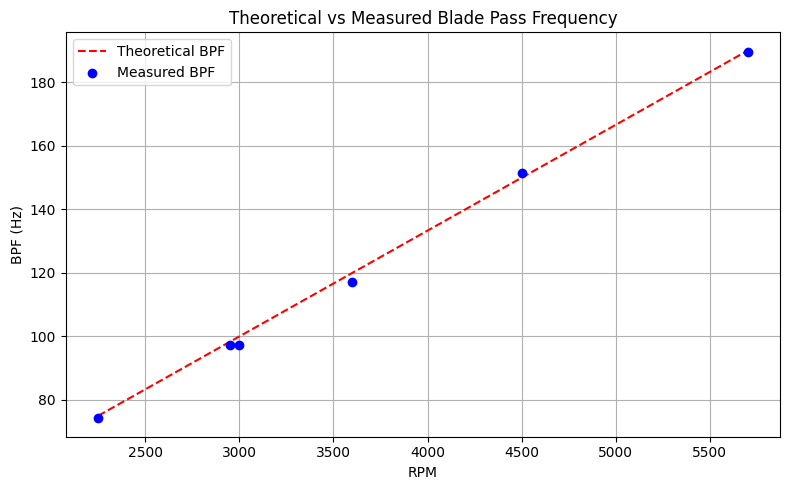

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(df['RPM'], df['Expected_BPF_Hz'], 'r--', label='Theoretical BPF')
plt.scatter(df['RPM'], df['Measured_BPF_Hz'], color='blue', zorder=5, label='Measured BPF')
plt.xlabel('RPM')
plt.ylabel('BPF (Hz)')
plt.title('Theoretical vs Measured Blade Pass Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('fig1_bpf_vs_rpm.png', dpi=150)
plt.show()

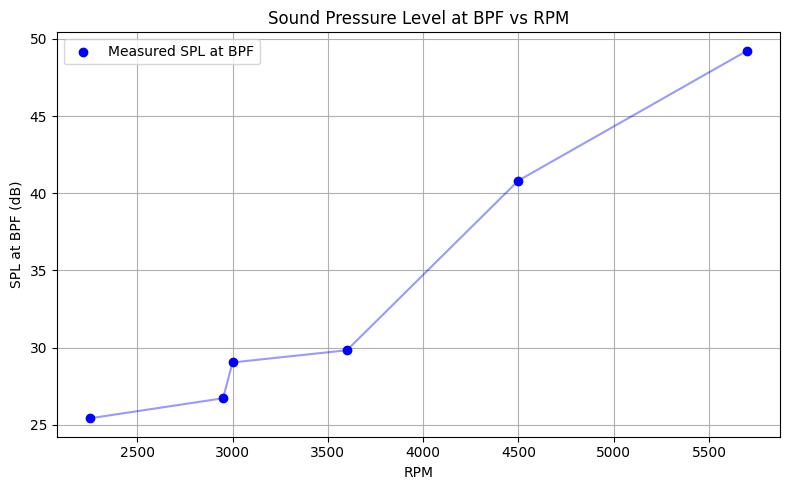

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(df['RPM'], df['SPL_at_BPF_dB'], color='blue', zorder=5, label='Measured SPL at BPF')
plt.plot(df['RPM'], df['SPL_at_BPF_dB'], 'b-', alpha=0.4)
plt.xlabel('RPM')
plt.ylabel('SPL at BPF (dB)')
plt.title('Sound Pressure Level at BPF vs RPM')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('fig2_spl_vs_rpm.png', dpi=150)
plt.show()

  Found 83 files
  Found 28 files
  Found 51 files
  Found 30 files


C:\Users\Isha Kulshrestha\AppData\Local\Temp\ipykernel_3984\1193595641.py:2: UserWarning: loadtxt: input contained no data: "C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\data\90_Deg\RPM3600\T1_30.lvm"
  data = np.loadtxt(filepath, skiprows=SKIPROWS, delimiter='\t')


  Found 39 files


C:\Users\Isha Kulshrestha\AppData\Local\Temp\ipykernel_3984\1193595641.py:2: UserWarning: loadtxt: input contained no data: "C:\Users\Isha Kulshrestha\Desktop\IshaAcoustics\DroneNoiseNITC\data\90_Deg\RPM4500\T1_39.lvm"
  data = np.loadtxt(filepath, skiprows=SKIPROWS, delimiter='\t')


  Found 28 files


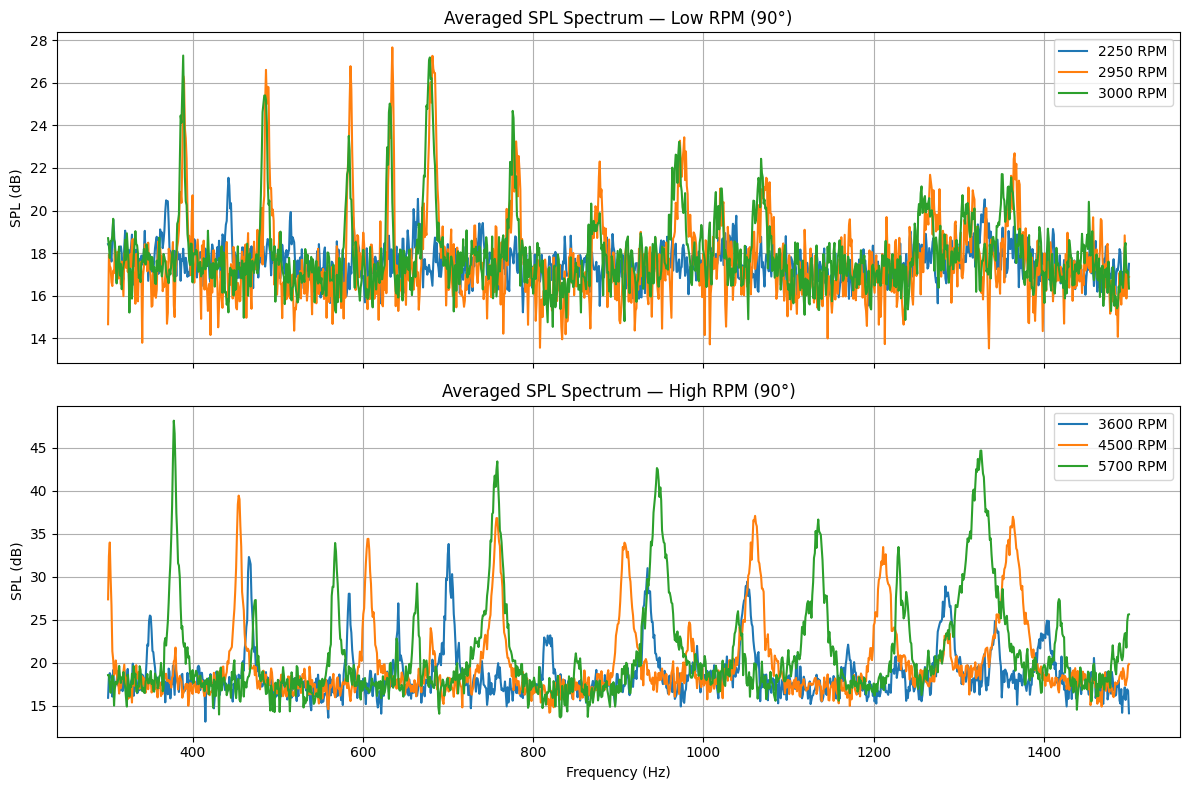

In [28]:
low_rpms = [2250, 2950, 3000]
high_rpms = [3600, 4500, 5700]

spectra_cache = {}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for rpm, folder in RPM_FOLDERS.items():
    freqs, avg_spl = load_and_average(folder)
    if freqs is None:
        continue
    spectra_cache[rpm] = (freqs, avg_spl)
    mask = (freqs >= 300) & (freqs <= 1500)
    if rpm in low_rpms:
        ax1.plot(freqs[mask], avg_spl[mask], label=f'{rpm} RPM')
    else:
        ax2.plot(freqs[mask], avg_spl[mask], label=f'{rpm} RPM')

for ax in [ax1, ax2]:
    ax.set_ylabel('SPL (dB)')
    ax.legend()
    ax.grid(True)

ax2.set_xlabel('Frequency (Hz)')
ax1.set_title('Averaged SPL Spectrum — Low RPM (90°)')
ax2.set_title('Averaged SPL Spectrum — High RPM (90°)')
plt.tight_layout()
plt.savefig('fig3_spectra.png', dpi=150)
plt.show()